<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/GPU_Accelerated_Monte_Carlo_Simulation_of_Tornado_Resilient_Courtyard_Concept.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [2]:
!uv pip install --system -q cupy-cuda12x k3d ipywidgets pandas matplotlib


Model scope
1. EF5 wind is sampled conditionally from a broad 201-320 mph triangular distribution with a 250 mph mode.
2. Wind pressure uses 0.5*rho*V^2 multiplied by stochastic tornado pressure and dynamic factors. This is a screening surrogate, not a full ASCE 7-22 Chapter 32 implementation.
3. Reinforced-concrete flexure and shear are reduced-order section checks with uncertain material and construction properties.
4. The foundation term is a probabilistic reserve-factor surrogate. Geotechnical, mat, anchorage, sliding, uplift, and soil-structure interaction analyses are outside this script.
5. Debris uses an energy-equivalent proxy anchored to the familiar 15 lb 2x4 / 100 mph storm-shelter missile criterion. Real assemblies must be physically tested to the applicable standard.
6. The four monoliths are roofless and contain three ground-level cut-throughs each. Occupant debris exposure in the courtyard is not counted as shell failure.
CUDA configuration
GPU                         

,width_m,depth_m,height_m,monolith_base_depth_m,rc_wall_thickness_m,top_scale,courtyard_width_m,courtyard_depth_m,concrete_volume_m3,survival_probability,failure_count,failure_upper_95,mean_utilization,max_utilization,passes_target,footprint_m2,height_to_min_plan
0,73.18,69.79,10.92,10.48,1.55,0.743,52.22,48.82,7829.0,0.999451,36,0.000760,0.303,1.446,True,5107.0,0.157
1,67.77,67.32,11.36,8.68,1.56,0.738,50.42,49.97,7863.0,0.999451,36,0.000760,0.305,1.443,True,4562.0,0.169
2,77.42,64.99,10.30,8.00,1.52,0.838,61.43,49.00,7923.0,0.999359,42,0.000866,0.304,1.464,True,5032.0,0.158
3,78.36,77.29,10.11,11.34,1.59,0.713,55.68,54.62,7961.0,0.999527,31,0.000671,0.295,1.425,True,6057.0,0.131
4,71.89,65.95,10.91,7.17,1.60,0.710,57.54,51.60,8013.0,0.999542,30,0.000653,0.296,1.420,True,4741.0,0.165
5,72.40,71.50,11.50,11.67,1.53,0.753,49.06,48.16,8079.0,0.999405,39,0.000813,0.310,1.457,True,5177.0,0.161
6,69.48,66.93,11.48,7.77,1.50,0.786,53.93,51.39,8106.0,0.999313,45,0.000919,0.314,1.472,True,4650.0,0.172
7,66.47,64.69,12.24,8.08,1.50,0.767,50.31,48.53,8144.0,0.999313,45,0.000919,0.321,1.471,True,4300.0,0.189
8,83.04,71.98,10.82,11.29,1.55,0.711,60.46,49.40,8246.0,0.999435,37,0.000778,0.302,1.446,True,5977.0,0.150
9,69.67,65.14,10.68,7.31,1.68,0.774,55.05,50.52,8311.0,0.999619,25,0.000563,0.287,1.386,True,4539.0,0.164


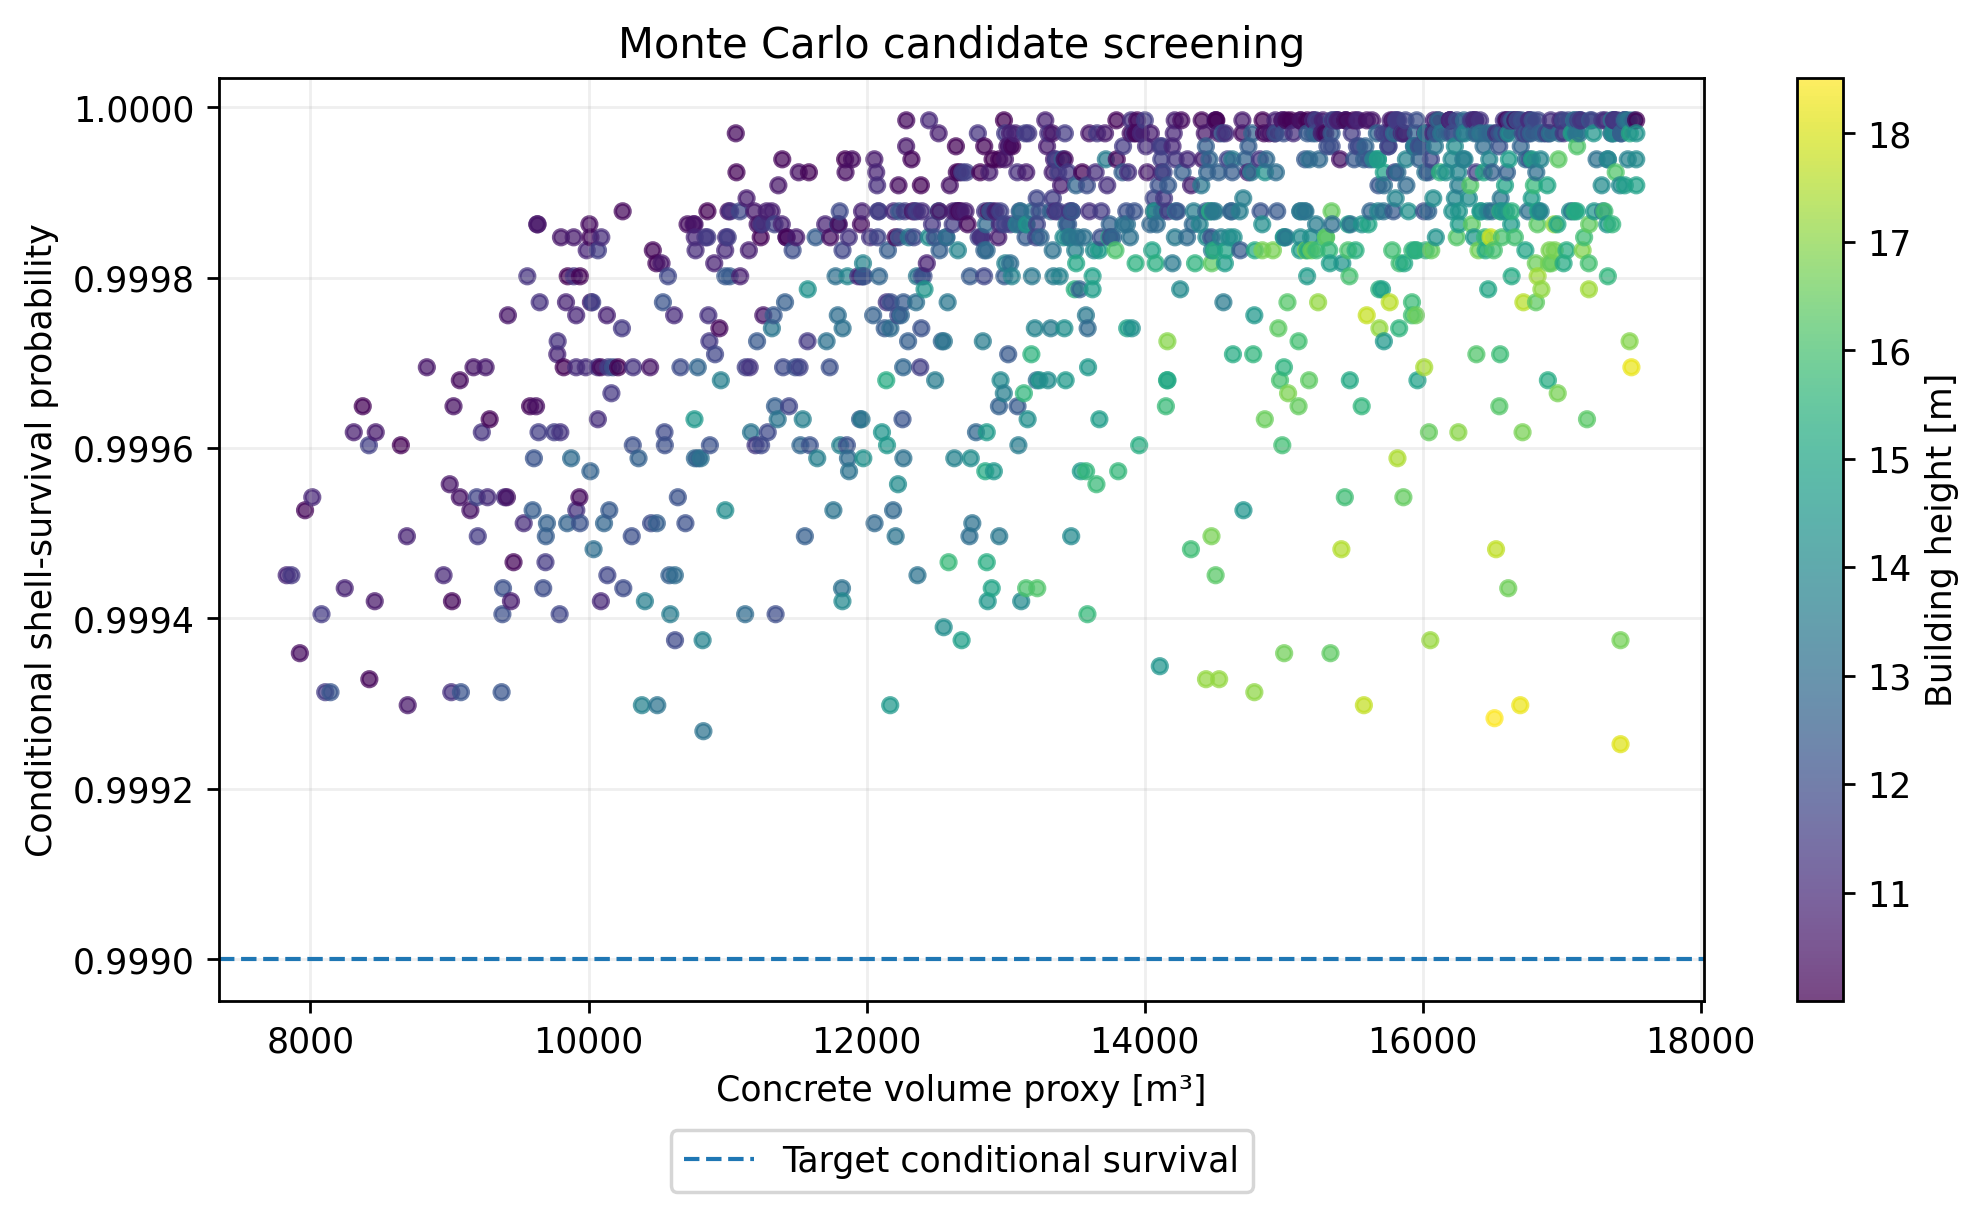

Selected footprint: 5,107.1 m²

Running high-statistics final Monte Carlo...
Final Monte Carlo:  1,000,000/10,000,000 trials
Final Monte Carlo:  2,000,000/10,000,000 trials
Final Monte Carlo:  3,000,000/10,000,000 trials
Final Monte Carlo:  4,000,000/10,000,000 trials
Final Monte Carlo:  5,000,000/10,000,000 trials
Final Monte Carlo:  6,000,000/10,000,000 trials
Final Monte Carlo:  7,000,000/10,000,000 trials
Final Monte Carlo:  8,000,000/10,000,000 trials
Final Monte Carlo:  9,000,000/10,000,000 trials
Final Monte Carlo: 10,000,000/10,000,000 trials
Final throughput              : 58.4 M trials/s

Selected conceptual geometry
Outer width                  :    73.18 m
Outer depth                  :    69.79 m
Height                       :    10.92 m
Monolith base depth          :    10.48 m
Monolith top depth           :     7.79 m
RC shell wall thickness      :     1.55 m
Courtyard width              :    52.22 m
Courtyard depth              :    48.82 m
N/S opening width each       

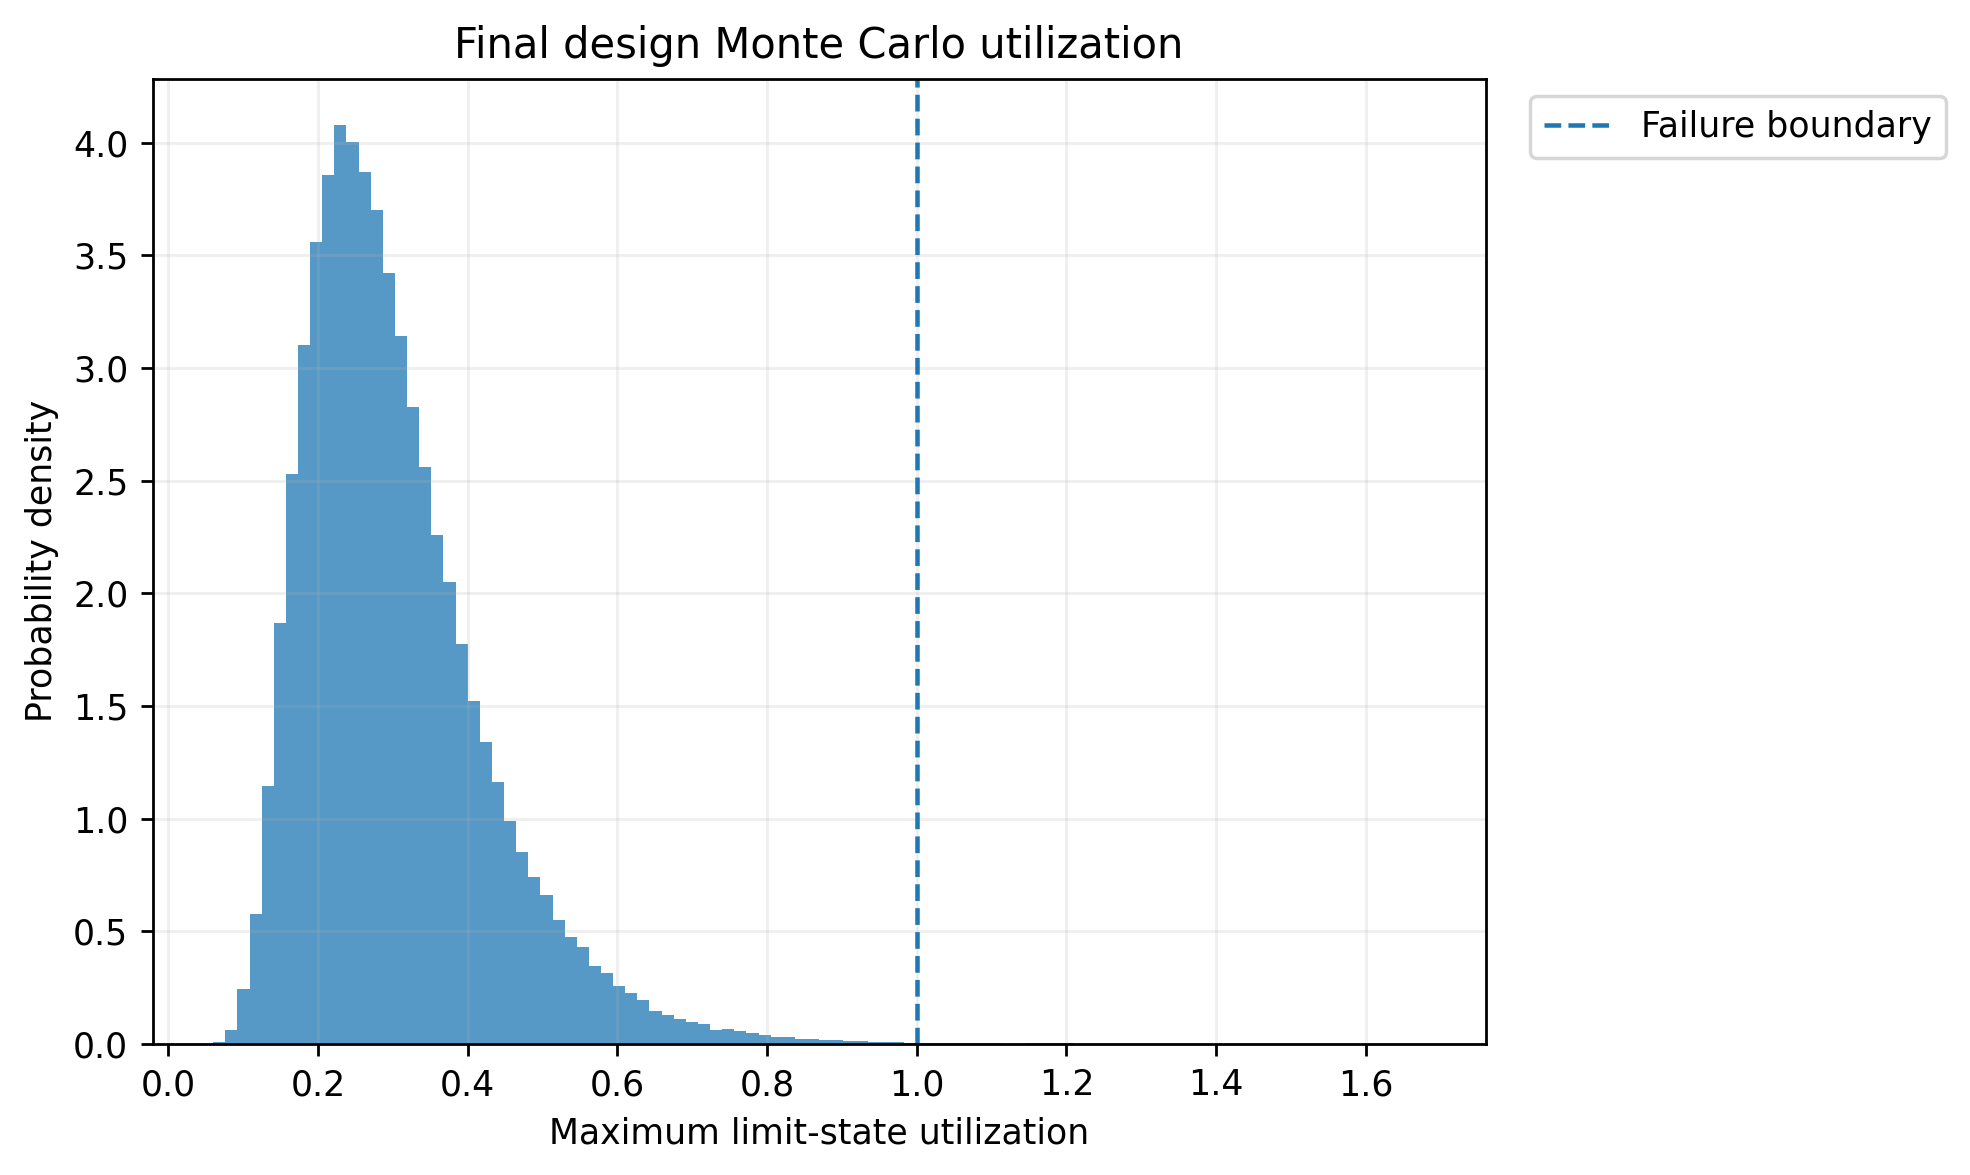


Interactive K3D geometry
Rotate and zoom the model. The outer rectangle is the 100 m x 100 m city block; the inner outline is the approximate courtyard.


/tmp/ipykernel_717/1277668940.py:1258: DeprecationWarning:

switch_to_text_protocol() is deprecated since 3.0.0 - the binary protocol works everywhere, including Google Colab.



In [4]:
"""GPU Monte Carlo screening study for a roofless tornado-resilient courtyard concept.

This Google Colab-oriented script explores a conceptual building formed by four
tapered reinforced-concrete monoliths surrounding an open courtyard. Each
monolith contains three large rectangular ground-level cut-throughs. CuPy
evaluates a conditional EF5 wind/debris screening model on a CUDA GPU, then
K3D renders the selected geometry interactively.

This is a research and pre-design screening model. It does not implement the
full ASCE 7-22 Chapter 32, ICC 500, FEMA P-361, ACI 318, foundation, connection,
progressive-collapse, CFD, or impact-testing procedures needed for a real
building or life-safety shelter.
"""

from dataclasses import dataclass
import math
import time
from typing import NamedTuple

import cupy as cp
import k3d
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display


# - Reproducibility and GPU controls -----------------------------------------

RANDOM_SEED = 20260905
GPU_MEMORY_FRACTION = 0.90
AGGRESSIVE_L4_MODE = True
GPU_FLOAT_DTYPE = cp.float32

# Search load. Reduce these first if a shared Colab runtime is constrained.
SEARCH_CANDIDATES = 4096 if AGGRESSIVE_L4_MODE else 1024
SEARCH_TRIALS = 65_536 if AGGRESSIVE_L4_MODE else 32_768
FINAL_TRIALS = 10_000_000 if AGGRESSIVE_L4_MODE else 1_000_000
FINAL_CHUNK_TRIALS = 1_000_000 if AGGRESSIVE_L4_MODE else 250_000
MAX_CANDIDATE_BATCH = 512 if AGGRESSIVE_L4_MODE else 128

# Estimate of peak temporary storage per candidate-trial evaluation. This is
# intentionally conservative so CuPy has headroom for temporary arrays.
ESTIMATED_BYTES_PER_EVALUATION = 224
MEMORY_HEADROOM_FRACTION = 0.72

# - City-block and architectural controls -----------------------------------

BLOCK_WIDTH_M = 100.0
BLOCK_DEPTH_M = 100.0
MIN_BLOCK_EDGE_CLEARANCE_M = 5.0

# Minimum architectural utility constraints.
MIN_COURTYARD_WIDTH_M = 48.0
MIN_COURTYARD_DEPTH_M = 48.0
MIN_HEIGHT_M = 10.0
MAX_HEIGHT_M = 22.0

# Candidate outer footprint range.
MIN_OUTER_WIDTH_M = 64.0
MAX_OUTER_WIDTH_M = BLOCK_WIDTH_M - 2.0 * MIN_BLOCK_EDGE_CLEARANCE_M
MIN_OUTER_DEPTH_M = 64.0
MAX_OUTER_DEPTH_M = BLOCK_DEPTH_M - 2.0 * MIN_BLOCK_EDGE_CLEARANCE_M

# Monolith base depth is the tapered transverse architectural depth of each wing.
MIN_MONOLITH_BASE_DEPTH_M = 7.0
MAX_MONOLITH_BASE_DEPTH_M = 12.0
MIN_RC_WALL_THICKNESS_M = 0.75
MAX_RC_WALL_THICKNESS_M = 3.00
MIN_TOP_SCALE = 0.68
MAX_TOP_SCALE = 0.85

# Additional transverse walls, piers, and diaphragms are represented as a
# fraction of the two long-shell wall volumes. The K3D model shows the
# architectural massing envelope rather than a literal solid concrete fill.
DIAPHRAGM_VOLUME_FACTOR = 0.25

# Each monolith contains exactly three rectangular cut-throughs.
OPENINGS_PER_MONOLITH = 3
OPENING_WIDTH_FRACTION = 0.10
OPENING_HEIGHT_FRACTION = 0.40

# Initial concept shown before optimization.
INITIAL_WIDTH_M = 72.0
INITIAL_DEPTH_M = 72.0
INITIAL_HEIGHT_M = 12.0
INITIAL_MONOLITH_BASE_DEPTH_M = 8.0
INITIAL_RC_WALL_THICKNESS_M = 1.50
INITIAL_TOP_SCALE = 0.75

# - Reliability target -------------------------------------------------------

# Conditional structural-shell survival probability under the hazard model.
# This is a model target, not a code-prescribed life-safety probability.
TARGET_CONDITIONAL_SURVIVAL = 0.999

# Search candidates must satisfy the target using the raw Monte Carlo
# survival estimate and the 95% Wilson upper confidence bound on failure.
# - EF5 hazard model controls ------------------------------------------------

# EF5 is officially >200 mph. The upper tail has no EF-scale cap, so this
# screening model uses a deliberately broad triangular distribution.
EF5_WIND_MIN_MPH = 201.0
EF5_WIND_MODE_MPH = 250.0
EF5_WIND_MAX_MPH = 320.0

AIR_DENSITY_MEAN_KG_M3 = 1.18
AIR_DENSITY_STD_KG_M3 = 0.06

# Peak net pressure multiplier combines uncertain surface pressure,
# tornado-flow amplification, and imperfect pressure equalization.
PRESSURE_COEFF_MIN = 1.20
PRESSURE_COEFF_MODE = 1.80
PRESSURE_COEFF_MAX = 2.70

DYNAMIC_AMPLIFICATION_LOG_MEAN = 0.0
DYNAMIC_AMPLIFICATION_LOG_STD = 0.18

# Large openings can equalize some mean pressure but can also create local
# jets and concentration around piers/spandrels.
OPENING_RELIEF_MIN = 0.10
OPENING_RELIEF_MAX = 0.55
OPENING_JET_MIN = 0.10
OPENING_JET_MAX = 0.65

# - Reinforced-concrete screening controls ----------------------------------

CONCRETE_FC_MEAN_MPA = 69.0
CONCRETE_FC_STD_MPA = 7.0
CONCRETE_FC_MIN_MPA = 45.0
CONCRETE_FC_MAX_MPA = 95.0

STEEL_FY_MEAN_MPA = 500.0
STEEL_FY_STD_MPA = 30.0
STEEL_FY_MIN_MPA = 420.0
STEEL_FY_MAX_MPA = 600.0

VERTICAL_REBAR_RATIO_MEAN = 0.010
VERTICAL_REBAR_RATIO_STD = 0.0015
VERTICAL_REBAR_RATIO_MIN = 0.006
VERTICAL_REBAR_RATIO_MAX = 0.016

CONCRETE_DENSITY_MEAN_KG_M3 = 2450.0
CONCRETE_DENSITY_STD_KG_M3 = 70.0

FLEXURE_PHI = 0.90
SHEAR_PHI = 0.75
EFFECTIVE_DEPTH_FRACTION = 0.86
GRAVITY_M_S2 = 9.80665

# Uncertainty in continuity, reinforcement placement, joints, and construction.
CAPACITY_QUALITY_MIN = 0.78
CAPACITY_QUALITY_MAX = 1.00

# Foundation/load-path screening factor. A real design needs explicit soil,
# mat/grade-beam, anchorage, sliding, uplift, and connection calculations.
FOUNDATION_FACTOR_MIN = 0.75
FOUNDATION_FACTOR_MAX = 1.10

# - Tornado-borne debris screening proxy ------------------------------------

# FEMA/ICC storm-shelter testing commonly uses a 15 lb 2x4 at up to 100 mph
# in the 250 mph tornado wind zone. The model below is an energy-equivalent
# screening proxy only; it is not an impact-test substitute.
REFERENCE_MISSILE_MASS_LB = 15.0
REFERENCE_MISSILE_SPEED_MPH = 100.0
REFERENCE_RC_THICKNESS_M = 0.30
REFERENCE_FC_MPA = 40.0
REFERENCE_REBAR_RATIO = 0.006

DEBRIS_WIND_FRACTION_MIN = 0.20
DEBRIS_WIND_FRACTION_MODE = 0.40
DEBRIS_WIND_FRACTION_MAX = 0.60
DEBRIS_LOG_MASS_MEDIAN_LB = 15.0
DEBRIS_LOG_MASS_SIGMA = 0.65
DEBRIS_MASS_MAX_LB = 250.0

# - Visualization controls ---------------------------------------------------

K3D_BACKGROUND = 0x101214
K3D_CONCRETE_COLOR = 0xB7B3A8
K3D_BLOCK_COLOR = 0x7B8794
K3D_COURTYARD_COLOR = 0x6F8F72
K3D_OPACITY = 0.92

mpl.rcParams["figure.dpi"] = 250
mpl.rcParams["savefig.dpi"] = 250


@dataclass(frozen=True)
class Design:
    """Defines one four-monolith courtyard design."""

    width_m: float
    depth_m: float
    height_m: float
    monolith_base_depth_m: float
    rc_wall_thickness_m: float
    top_scale: float

    @property
    def courtyard_width_m(self) -> float:
        """Returns the approximate clear courtyard width."""
        return self.width_m - 2.0 * self.monolith_base_depth_m

    @property
    def courtyard_depth_m(self) -> float:
        """Returns the approximate clear courtyard depth."""
        return self.depth_m - 2.0 * self.monolith_base_depth_m


class HazardSamples(NamedTuple):
    """CuPy arrays containing stochastic hazard and capacity variables."""

    wind_mph: cp.ndarray
    air_density: cp.ndarray
    pressure_coeff: cp.ndarray
    dynamic_amp: cp.ndarray
    angle_rad: cp.ndarray
    opening_relief: cp.ndarray
    opening_jet: cp.ndarray
    fc_pa: cp.ndarray
    fy_pa: cp.ndarray
    rebar_ratio: cp.ndarray
    concrete_density: cp.ndarray
    capacity_quality: cp.ndarray
    foundation_factor: cp.ndarray
    debris_mass_lb: cp.ndarray
    debris_wind_fraction: cp.ndarray


@dataclass(frozen=True)
class BatchMetrics:
    """GPU-computed reliability metrics for a candidate batch."""

    survival: np.ndarray
    failure_count: np.ndarray
    failure_upper_95: np.ndarray
    mean_utilization: np.ndarray
    max_utilization: np.ndarray


def mph_to_mps(speed_mph: cp.ndarray | float) -> cp.ndarray | float:
    """Converts miles per hour to meters per second."""
    return speed_mph * 0.44704


def _triangular_gpu(
    size: int,
    low: float,
    mode: float,
    high: float,
    dtype: cp.dtype = GPU_FLOAT_DTYPE,
) -> cp.ndarray:
    """Samples a triangular distribution using CuPy primitives."""
    if not low <= mode <= high:
        raise ValueError("Triangular distribution requires low <= mode <= high.")

    u = cp.random.random(size, dtype=dtype)
    c = (mode - low) / (high - low)
    left = low + cp.sqrt(u * (high - low) * (mode - low))
    right = high - cp.sqrt((1.0 - u) * (high - low) * (high - mode))
    return cp.where(u < c, left, right).astype(dtype, copy=False)


def _truncated_normal_gpu(
    size: int,
    mean: float,
    std: float,
    low: float,
    high: float,
) -> cp.ndarray:
    """Samples a clipped normal distribution on the GPU."""
    samples = mean + std * cp.random.standard_normal(size, dtype=GPU_FLOAT_DTYPE)
    return cp.clip(samples, low, high)


def _uniform_gpu(size: int, low: float, high: float) -> cp.ndarray:
    """Samples a float32 uniform distribution on the GPU."""
    unit = cp.random.random(size, dtype=GPU_FLOAT_DTYPE)
    return low + (high - low) * unit


def configure_gpu() -> dict[str, float | str]:
    """Configures CuPy memory handling and reports the active CUDA device."""
    device_count = cp.cuda.runtime.getDeviceCount()
    if device_count < 1:
        raise RuntimeError("No CUDA GPU is visible to CuPy.")

    cp.cuda.Device(0).use()
    properties = cp.cuda.runtime.getDeviceProperties(0)
    raw_name = properties.get("name", b"Unknown CUDA GPU")
    name = raw_name.decode() if isinstance(raw_name, bytes) else str(raw_name)

    free_bytes, total_bytes = cp.cuda.runtime.memGetInfo()
    memory_pool = cp.get_default_memory_pool()
    pinned_pool = cp.get_default_pinned_memory_pool()

    try:
        memory_pool.set_limit(fraction=GPU_MEMORY_FRACTION)
    except (AttributeError, TypeError, ValueError):
        # CuPy versions vary slightly in MemoryPool.set_limit behavior.
        pass

    cp.random.seed(RANDOM_SEED)

    print("CUDA configuration")
    print("=" * 72)
    print(f"GPU                         : {name}")
    print(f"Free memory                 : {free_bytes / 2**30:.2f} GiB")
    print(f"Total memory                : {total_bytes / 2**30:.2f} GiB")
    print(f"CuPy pool target            : {GPU_MEMORY_FRACTION:.0%}")
    print(f"Aggressive L4 mode          : {AGGRESSIVE_L4_MODE}")
    print(f"Search candidates           : {SEARCH_CANDIDATES:,}")
    print(f"Search trials/candidate     : {SEARCH_TRIALS:,}")
    print(f"Final trials                : {FINAL_TRIALS:,}")
    print("=" * 72)

    if "L4" not in name.upper():
        print(
            "Warning: the active GPU does not report itself as an NVIDIA L4. "
            "The adaptive batcher will still use the available CUDA memory."
        )

    return {
        "name": name,
        "free_bytes": float(free_bytes),
        "total_bytes": float(total_bytes),
        "pool_used_bytes": float(memory_pool.used_bytes()),
        "pinned_pool_bytes": float(pinned_pool.n_free_blocks()),
    }


def adaptive_candidate_batch_size(free_bytes: float) -> int:
    """Returns a candidate batch size based on available GPU memory."""
    budget = free_bytes * MEMORY_HEADROOM_FRACTION
    bytes_per_candidate = SEARCH_TRIALS * ESTIMATED_BYTES_PER_EVALUATION
    estimated = int(max(1, budget // max(bytes_per_candidate, 1)))
    batch = min(MAX_CANDIDATE_BATCH, estimated)
    return max(8, batch)


def sample_hazards(n_trials: int) -> HazardSamples:
    """Samples EF5 conditional hazard and material variables on the GPU."""
    wind_mph = _triangular_gpu(
        n_trials,
        EF5_WIND_MIN_MPH,
        EF5_WIND_MODE_MPH,
        EF5_WIND_MAX_MPH,
    )

    air_density = _truncated_normal_gpu(
        n_trials,
        AIR_DENSITY_MEAN_KG_M3,
        AIR_DENSITY_STD_KG_M3,
        0.95,
        1.30,
    )
    pressure_coeff = _triangular_gpu(
        n_trials,
        PRESSURE_COEFF_MIN,
        PRESSURE_COEFF_MODE,
        PRESSURE_COEFF_MAX,
    )

    dynamic_amp = cp.exp(
        DYNAMIC_AMPLIFICATION_LOG_MEAN
        + DYNAMIC_AMPLIFICATION_LOG_STD
        * cp.random.standard_normal(n_trials, dtype=GPU_FLOAT_DTYPE)
    )
    dynamic_amp = cp.clip(dynamic_amp, 0.70, 1.80)

    angle_rad = _uniform_gpu(n_trials, 0.0, 2.0 * math.pi)
    opening_relief = _uniform_gpu(
        n_trials,
        OPENING_RELIEF_MIN,
        OPENING_RELIEF_MAX,
    )
    opening_jet = _uniform_gpu(
        n_trials,
        OPENING_JET_MIN,
        OPENING_JET_MAX,
    )

    fc_mpa = _truncated_normal_gpu(
        n_trials,
        CONCRETE_FC_MEAN_MPA,
        CONCRETE_FC_STD_MPA,
        CONCRETE_FC_MIN_MPA,
        CONCRETE_FC_MAX_MPA,
    )
    fy_mpa = _truncated_normal_gpu(
        n_trials,
        STEEL_FY_MEAN_MPA,
        STEEL_FY_STD_MPA,
        STEEL_FY_MIN_MPA,
        STEEL_FY_MAX_MPA,
    )
    rebar_ratio = _truncated_normal_gpu(
        n_trials,
        VERTICAL_REBAR_RATIO_MEAN,
        VERTICAL_REBAR_RATIO_STD,
        VERTICAL_REBAR_RATIO_MIN,
        VERTICAL_REBAR_RATIO_MAX,
    )

    concrete_density = _truncated_normal_gpu(
        n_trials,
        CONCRETE_DENSITY_MEAN_KG_M3,
        CONCRETE_DENSITY_STD_KG_M3,
        2250.0,
        2650.0,
    )

    capacity_quality = _uniform_gpu(
        n_trials,
        CAPACITY_QUALITY_MIN,
        CAPACITY_QUALITY_MAX,
    )
    foundation_factor = _uniform_gpu(
        n_trials,
        FOUNDATION_FACTOR_MIN,
        FOUNDATION_FACTOR_MAX,
    )

    debris_mass_lb = cp.exp(
        math.log(DEBRIS_LOG_MASS_MEDIAN_LB)
        + DEBRIS_LOG_MASS_SIGMA
        * cp.random.standard_normal(n_trials, dtype=GPU_FLOAT_DTYPE)
    )
    debris_mass_lb = cp.clip(debris_mass_lb, 1.0, DEBRIS_MASS_MAX_LB)
    debris_wind_fraction = _triangular_gpu(
        n_trials,
        DEBRIS_WIND_FRACTION_MIN,
        DEBRIS_WIND_FRACTION_MODE,
        DEBRIS_WIND_FRACTION_MAX,
    )

    return HazardSamples(
        wind_mph=wind_mph,
        air_density=air_density,
        pressure_coeff=pressure_coeff,
        dynamic_amp=dynamic_amp,
        angle_rad=angle_rad,
        opening_relief=opening_relief,
        opening_jet=opening_jet,
        fc_pa=fc_mpa * 1.0e6,
        fy_pa=fy_mpa * 1.0e6,
        rebar_ratio=rebar_ratio,
        concrete_density=concrete_density,
        capacity_quality=capacity_quality,
        foundation_factor=foundation_factor,
        debris_mass_lb=debris_mass_lb,
        debris_wind_fraction=debris_wind_fraction,
    )


def _integral_scale_squared(height_m: cp.ndarray, top_scale: cp.ndarray) -> cp.ndarray:
    """Returns integral of squared linear taper scale from z=0 to H."""
    return height_m * (1.0 + top_scale + top_scale**2) / 3.0


def _lower_integral_scale_squared(
    height_m: cp.ndarray,
    top_scale: cp.ndarray,
    lower_fraction: float,
) -> cp.ndarray:
    """Returns squared-scale integral from zero to a fractional height."""
    k = 1.0 - top_scale
    r = lower_fraction
    return height_m * (r - k * r**2 + (k**2) * r**3 / 3.0)


def _integral_scale_linear(
    height_m: cp.ndarray,
    top_scale: cp.ndarray,
) -> cp.ndarray:
    """Returns integral of the linear taper scale from z=0 to H."""
    return height_m * (1.0 + top_scale) / 2.0


def _lower_integral_scale_linear(
    height_m: cp.ndarray,
    top_scale: cp.ndarray,
    lower_fraction: float,
) -> cp.ndarray:
    """Returns linear-scale integral from zero to a fractional height."""
    k = 1.0 - top_scale
    r = lower_fraction
    return height_m * (r - 0.5 * k * r**2)


def concrete_volume_gpu(
    width_m: cp.ndarray,
    depth_m: cp.ndarray,
    height_m: cp.ndarray,
    monolith_depth_m: cp.ndarray,
    wall_thickness_m: cp.ndarray,
    top_scale: cp.ndarray,
) -> cp.ndarray:
    """Estimates reinforced-concrete shell volume with twelve cut-throughs."""
    inner_width = cp.maximum(width_m - 2.0 * monolith_depth_m, 1.0)
    inner_depth = cp.maximum(depth_m - 2.0 * monolith_depth_m, 1.0)

    outer_perimeter = 2.0 * (width_m + depth_m)
    inner_perimeter = 2.0 * (inner_width + inner_depth)
    total_wall_length = outer_perimeter + inner_perimeter

    integral_total = _integral_scale_linear(height_m, top_scale)
    integral_lower = _lower_integral_scale_linear(
        height_m,
        top_scale,
        OPENING_HEIGHT_FRACTION,
    )
    removed_length_fraction = (
        OPENINGS_PER_MONOLITH * OPENING_WIDTH_FRACTION
    )
    effective_integral = (
        integral_total - removed_length_fraction * integral_lower
    )

    longitudinal_shell = (
        total_wall_length
        * wall_thickness_m
        * effective_integral
    )
    return longitudinal_shell * (1.0 + DIAPHRAGM_VOLUME_FACTOR)


def concrete_volume_cpu(design: Design) -> float:
    """Returns the reinforced-concrete shell-volume estimate."""
    inner_width = max(
        design.width_m - 2.0 * design.monolith_base_depth_m,
        1.0,
    )
    inner_depth = max(
        design.depth_m - 2.0 * design.monolith_base_depth_m,
        1.0,
    )
    total_wall_length = (
        2.0 * (design.width_m + design.depth_m)
        + 2.0 * (inner_width + inner_depth)
    )

    integral_total = (
        design.height_m * (1.0 + design.top_scale) / 2.0
    )
    k = 1.0 - design.top_scale
    r = OPENING_HEIGHT_FRACTION
    integral_lower = design.height_m * (
        r - 0.5 * k * r**2
    )
    removed_length_fraction = (
        OPENINGS_PER_MONOLITH * OPENING_WIDTH_FRACTION
    )
    effective_integral = (
        integral_total - removed_length_fraction * integral_lower
    )
    longitudinal_shell = (
        total_wall_length
        * design.rc_wall_thickness_m
        * effective_integral
    )
    return longitudinal_shell * (1.0 + DIAPHRAGM_VOLUME_FACTOR)


def _design_arrays(designs: list[Design]) -> tuple[cp.ndarray, ...]:
    """Converts a design list into broadcastable CuPy column vectors."""
    def column(values: list[float]) -> cp.ndarray:
        return cp.asarray(values, dtype=GPU_FLOAT_DTYPE)[:, None]

    return (
        column([d.width_m for d in designs]),
        column([d.depth_m for d in designs]),
        column([d.height_m for d in designs]),
        column([d.monolith_base_depth_m for d in designs]),
        column([d.rc_wall_thickness_m for d in designs]),
        column([d.top_scale for d in designs]),
    )


def utilization_matrix(
    designs: list[Design],
    hazard: HazardSamples,
) -> cp.ndarray:
    """Returns the maximum limit-state utilization per design and trial.

    The four modeled screening limit states are global overturning, wall-base
    flexure, wall-base shear, and a calibrated debris-energy proxy.
    """
    (
        width,
        depth,
        height,
        monolith_depth,
        wall_thickness,
        top_scale,
    ) = _design_arrays(designs)

    cos_abs = cp.abs(cp.cos(hazard.angle_rad))[None, :]
    sin_abs = cp.abs(cp.sin(hazard.angle_rad))[None, :]
    wind_mps = mph_to_mps(hazard.wind_mph)[None, :]

    # Broad face is selected according to the dominant incident component.
    width_face = width
    depth_face = depth
    face_length = cp.where(sin_abs >= cos_abs, width_face, depth_face)

    # A squared normal component captures directional pressure variation while
    # retaining a turbulent floor for non-normal flow.
    normal_component = cp.maximum(sin_abs, cos_abs)
    directional_factor = 0.25 + 0.75 * normal_component**2

    opening_area_fraction = (
        OPENINGS_PER_MONOLITH
        * OPENING_WIDTH_FRACTION
        * OPENING_HEIGHT_FRACTION
    )
    solid_area_fraction = 1.0 - opening_area_fraction

    pressure_relief = 1.0 - hazard.opening_relief[None, :] * opening_area_fraction
    jet_factor = 1.0 + hazard.opening_jet[None, :] * opening_area_fraction

    dynamic_pressure = (
        0.5
        * hazard.air_density[None, :]
        * wind_mps**2
        * hazard.pressure_coeff[None, :]
        * hazard.dynamic_amp[None, :]
    )
    net_pressure = dynamic_pressure * directional_factor * pressure_relief

    # Simplified cantilever-wall demand. A local jet factor increases demand
    # near piers and spandrels around the cut-throughs.
    solid_face_area = face_length * height * solid_area_fraction
    base_shear_demand = net_pressure * solid_face_area * jet_factor
    base_moment_demand = base_shear_demand * (0.55 * height)

    # Effective reinforced-concrete section at the base after subtracting the
    # total opening widths from the lower wall strip.
    ligament_fraction = 1.0 - OPENINGS_PER_MONOLITH * OPENING_WIDTH_FRACTION
    effective_b = face_length * ligament_fraction
    effective_d = EFFECTIVE_DEPTH_FRACTION * wall_thickness

    as_area = (
        hazard.rebar_ratio[None, :]
        * effective_b
        * effective_d
    )
    a_depth = (
        as_area
        * hazard.fy_pa[None, :]
        / (
            0.85
            * hazard.fc_pa[None, :]
            * cp.maximum(effective_b, 1.0e-3)
        )
    )
    a_depth = cp.minimum(a_depth, 0.75 * effective_d)

    flexure_capacity = (
        FLEXURE_PHI
        * as_area
        * hazard.fy_pa[None, :]
        * (effective_d - 0.5 * a_depth)
        * hazard.capacity_quality[None, :]
    )

    # ACI-style concrete shear term in MPa and mm units, converted to newtons.
    fc_mpa = hazard.fc_pa[None, :] / 1.0e6
    b_mm = effective_b * 1000.0
    d_mm = effective_d * 1000.0
    shear_capacity = (
        SHEAR_PHI
        * 0.17
        * cp.sqrt(fc_mpa)
        * b_mm
        * d_mm
        * hazard.capacity_quality[None, :]
    )

    flexure_utilization = base_moment_demand / cp.maximum(flexure_capacity, 1.0)
    shear_utilization = base_shear_demand / cp.maximum(shear_capacity, 1.0)

    # Global overturning uses total tapered mass and a direction-dependent
    # footprint lever arm. Foundation_factor captures conceptual anchorage and
    # soil/load-path uncertainty; it is not a foundation design calculation.
    volume = concrete_volume_gpu(
        width[:, 0],
        depth[:, 0],
        height[:, 0],
        monolith_depth[:, 0],
        wall_thickness[:, 0],
        top_scale[:, 0],
    )[:, None]
    weight = hazard.concrete_density[None, :] * volume * GRAVITY_M_S2
    global_force = net_pressure * solid_face_area
    overturning_demand = global_force * 0.55 * height

    plan_lever = 0.40 * (
        width * cos_abs + depth * sin_abs
    )
    overturning_capacity = (
        weight
        * plan_lever
        * hazard.foundation_factor[None, :]
        * hazard.capacity_quality[None, :]
    )
    overturning_utilization = overturning_demand / cp.maximum(
        overturning_capacity,
        1.0,
    )

    # Debris proxy. It scales an energy-equivalent impact velocity from a
    # reference reinforced-concrete panel and the sampled missile mass.
    fc_ratio = cp.sqrt(
        cp.maximum(
            hazard.fc_pa[None, :] / 1.0e6,
            1.0,
        )
        / REFERENCE_FC_MPA
    )
    rebar_ratio_factor = cp.sqrt(
        hazard.rebar_ratio[None, :] / REFERENCE_REBAR_RATIO
    )
    thickness_factor = (
        wall_thickness / REFERENCE_RC_THICKNESS_M
    ) ** 0.55

    equivalent_capacity_mph = (
        REFERENCE_MISSILE_SPEED_MPH
        * thickness_factor
        * fc_ratio
        * rebar_ratio_factor
        * hazard.capacity_quality[None, :]
    )

    debris_speed_mph = (
        hazard.wind_mph[None, :]
        * hazard.debris_wind_fraction[None, :]
    )
    mass_energy_factor = cp.sqrt(
        hazard.debris_mass_lb[None, :] / REFERENCE_MISSILE_MASS_LB
    )
    equivalent_debris_speed_mph = debris_speed_mph * mass_energy_factor
    debris_utilization = equivalent_debris_speed_mph / cp.maximum(
        equivalent_capacity_mph,
        1.0,
    )

    maximum = cp.maximum(flexure_utilization, shear_utilization)
    maximum = cp.maximum(maximum, overturning_utilization)
    maximum = cp.maximum(maximum, debris_utilization)
    return maximum.astype(GPU_FLOAT_DTYPE, copy=False)


def _wilson_upper_bound(
    failures: np.ndarray,
    trials: int,
    z_value: float = 1.959963984540054,
) -> np.ndarray:
    """Returns the two-sided 95% Wilson upper bound for failure probability."""
    if trials <= 0:
        raise ValueError("trials must be positive.")

    phat = failures.astype(np.float64) / float(trials)
    z2 = z_value**2
    denominator = 1.0 + z2 / trials
    center = phat + z2 / (2.0 * trials)
    radius = z_value * np.sqrt(
        phat * (1.0 - phat) / trials + z2 / (4.0 * trials**2)
    )
    return np.minimum(1.0, (center + radius) / denominator)


def evaluate_design_batch(
    designs: list[Design],
    hazard: HazardSamples,
) -> BatchMetrics:
    """Evaluates failure counts and utilization summaries for candidates."""
    utilization = utilization_matrix(designs, hazard)

    failure_count_gpu = cp.count_nonzero(utilization > 1.0, axis=1)
    survival = 1.0 - failure_count_gpu / utilization.shape[1]
    mean_utilization = cp.mean(utilization, axis=1)
    max_utilization = cp.max(utilization, axis=1)

    failure_count = cp.asnumpy(failure_count_gpu).astype(np.int64)
    failure_upper_95 = _wilson_upper_bound(
        failure_count,
        utilization.shape[1],
    )

    return BatchMetrics(
        survival=cp.asnumpy(survival),
        failure_count=failure_count,
        failure_upper_95=failure_upper_95,
        mean_utilization=cp.asnumpy(mean_utilization),
        max_utilization=cp.asnumpy(max_utilization),
    )


def initial_design() -> Design:
    """Returns the default concept used as a transparent starting point."""
    return Design(
        width_m=INITIAL_WIDTH_M,
        depth_m=INITIAL_DEPTH_M,
        height_m=INITIAL_HEIGHT_M,
        monolith_base_depth_m=INITIAL_MONOLITH_BASE_DEPTH_M,
        rc_wall_thickness_m=INITIAL_RC_WALL_THICKNESS_M,
        top_scale=INITIAL_TOP_SCALE,
    )


def generate_candidates(count: int) -> list[Design]:
    """Generates reproducible random candidates satisfying city-block limits."""
    rng = np.random.default_rng(RANDOM_SEED)
    candidates: list[Design] = []

    attempts = 0
    max_attempts = count * 20
    while len(candidates) < count and attempts < max_attempts:
        attempts += 1
        width = float(rng.uniform(MIN_OUTER_WIDTH_M, MAX_OUTER_WIDTH_M))
        depth = float(rng.uniform(MIN_OUTER_DEPTH_M, MAX_OUTER_DEPTH_M))
        height = float(rng.uniform(MIN_HEIGHT_M, MAX_HEIGHT_M))
        monolith_depth = float(
            rng.uniform(
                MIN_MONOLITH_BASE_DEPTH_M,
                MAX_MONOLITH_BASE_DEPTH_M,
            )
        )
        wall_thickness = float(
            rng.uniform(
                MIN_RC_WALL_THICKNESS_M,
                MAX_RC_WALL_THICKNESS_M,
            )
        )
        top_scale = float(rng.uniform(MIN_TOP_SCALE, MAX_TOP_SCALE))

        design = Design(
            width_m=width,
            depth_m=depth,
            height_m=height,
            monolith_base_depth_m=monolith_depth,
            rc_wall_thickness_m=wall_thickness,
            top_scale=top_scale,
        )

        if design.courtyard_width_m < MIN_COURTYARD_WIDTH_M:
            continue
        if design.courtyard_depth_m < MIN_COURTYARD_DEPTH_M:
            continue
        if width > BLOCK_WIDTH_M - 2.0 * MIN_BLOCK_EDGE_CLEARANCE_M:
            continue
        if depth > BLOCK_DEPTH_M - 2.0 * MIN_BLOCK_EDGE_CLEARANCE_M:
            continue
        candidates.append(design)

    if len(candidates) < count:
        raise RuntimeError(
            f"Only generated {len(candidates)} feasible candidates after "
            f"{attempts} attempts. Relax the architectural constraints."
        )
    return candidates


def search_designs(
    candidates: list[Design],
    hazard: HazardSamples,
    candidate_batch_size: int,
) -> pd.DataFrame:
    """Evaluates candidate designs and returns a ranked DataFrame."""
    records: list[dict[str, float | bool]] = []
    cp.cuda.runtime.deviceSynchronize()
    search_start = time.perf_counter()

    for start in range(0, len(candidates), candidate_batch_size):
        batch = candidates[start : start + candidate_batch_size]
        metrics = evaluate_design_batch(batch, hazard)

        for (
            design,
            survival,
            failure_count,
            failure_upper_95,
            mean_util,
            max_util,
        ) in zip(
            batch,
            metrics.survival,
            metrics.failure_count,
            metrics.failure_upper_95,
            metrics.mean_utilization,
            metrics.max_utilization,
            strict=True,
        ):
            volume = concrete_volume_cpu(design)
            target_failure = 1.0 - TARGET_CONDITIONAL_SURVIVAL
            passes = (
                survival >= TARGET_CONDITIONAL_SURVIVAL
                and failure_upper_95 <= target_failure
            )
            records.append(
                {
                    "width_m": design.width_m,
                    "depth_m": design.depth_m,
                    "height_m": design.height_m,
                    "monolith_base_depth_m": design.monolith_base_depth_m,
                    "rc_wall_thickness_m": design.rc_wall_thickness_m,
                    "top_scale": design.top_scale,
                    "courtyard_width_m": design.courtyard_width_m,
                    "courtyard_depth_m": design.courtyard_depth_m,
                    "concrete_volume_m3": volume,
                    "survival_probability": float(survival),
                    "failure_count": int(failure_count),
                    "failure_upper_95": float(failure_upper_95),
                    "mean_utilization": float(mean_util),
                    "max_utilization": float(max_util),
                    "passes_target": bool(passes),
                }
            )

        completed = min(start + len(batch), len(candidates))
        print(
            f"Search progress: {completed:>5,}/{len(candidates):,} candidates"
        )

        del metrics
        cp.get_default_memory_pool().free_all_blocks()

    cp.cuda.runtime.deviceSynchronize()
    elapsed = time.perf_counter() - search_start
    evaluations = len(candidates) * hazard.wind_mph.size
    print(
        "Search throughput             : "
        f"{evaluations / max(elapsed, 1.0e-9) / 1.0e6:,.1f} M "
        "candidate-trials/s"
    )

    results = pd.DataFrame.from_records(records)
    results["footprint_m2"] = results["width_m"] * results["depth_m"]
    results["height_to_min_plan"] = results["height_m"] / np.minimum(
        results["width_m"],
        results["depth_m"],
    )

    # Rank by minimum concrete volume among designs satisfying reliability.
    # Secondary terms prefer smaller footprint and smaller high-tail demand.
    results = results.sort_values(
        by=[
            "passes_target",
            "concrete_volume_m3",
            "footprint_m2",
            "failure_upper_95",
        ],
        ascending=[False, True, True, True],
    ).reset_index(drop=True)
    return results


def design_from_row(row: pd.Series) -> Design:
    """Builds a Design instance from a search result row."""
    return Design(
        width_m=float(row["width_m"]),
        depth_m=float(row["depth_m"]),
        height_m=float(row["height_m"]),
        monolith_base_depth_m=float(row["monolith_base_depth_m"]),
        rc_wall_thickness_m=float(row["rc_wall_thickness_m"]),
        top_scale=float(row["top_scale"]),
    )


def evaluate_final_design(
    design: Design,
    total_trials: int,
    chunk_trials: int,
) -> dict[str, float | np.ndarray]:
    """Runs the high-statistics final reliability simulation in GPU chunks."""
    completed = 0
    failures = 0
    utilization_chunks: list[cp.ndarray] = []
    cp.cuda.runtime.deviceSynchronize()
    final_start = time.perf_counter()

    while completed < total_trials:
        current = min(chunk_trials, total_trials - completed)
        hazard = sample_hazards(current)
        utilization = utilization_matrix([design], hazard)[0]

        failures += int(cp.count_nonzero(utilization > 1.0).get())
        utilization_chunks.append(utilization)
        completed += current

        print(f"Final Monte Carlo: {completed:>10,}/{total_trials:,} trials")
        del hazard
        cp.get_default_memory_pool().free_all_blocks()

    cp.cuda.runtime.deviceSynchronize()
    elapsed = time.perf_counter() - final_start
    print(
        "Final throughput              : "
        f"{total_trials / max(elapsed, 1.0e-9) / 1.0e6:,.1f} M trials/s"
    )

    all_utilization = cp.concatenate(utilization_chunks)
    survival = 1.0 - failures / total_trials

    metrics = {
        "survival_probability": survival,
        "failure_probability": failures / total_trials,
        "mean_utilization": float(cp.mean(all_utilization).get()),
        "p95_utilization": float(cp.percentile(all_utilization, 95.0).get()),
        "p99_utilization": float(cp.percentile(all_utilization, 99.0).get()),
        "p999_utilization": float(cp.percentile(all_utilization, 99.9).get()),
        "max_utilization": float(cp.max(all_utilization).get()),
        "utilization_sample": cp.asnumpy(
            all_utilization[
                :: max(1, total_trials // 200_000)
            ]
        ),
    }

    del all_utilization
    utilization_chunks.clear()
    cp.get_default_memory_pool().free_all_blocks()
    return metrics


def _opening_width(design: Design, wall_length_m: float) -> float:
    """Returns cut-through width for one wall."""
    del design
    return OPENING_WIDTH_FRACTION * wall_length_m


def _scale_at_height(design: Design, z_m: float) -> float:
    """Returns the linear taper scale at a given elevation."""
    fraction = np.clip(z_m / design.height_m, 0.0, 1.0)
    return 1.0 - (1.0 - design.top_scale) * fraction


def _frustum_segment_mesh(
    center_xy: tuple[float, float],
    base_x_bounds: tuple[float, float],
    base_y_bounds: tuple[float, float],
    z0_m: float,
    z1_m: float,
    design: Design,
) -> tuple[np.ndarray, np.ndarray]:
    """Creates vertices and triangle indices for one tapered wall segment."""
    cx, cy = center_xy
    x0, x1 = base_x_bounds
    y0, y1 = base_y_bounds

    scale0 = _scale_at_height(design, z0_m)
    scale1 = _scale_at_height(design, z1_m)

    def scale_x(x_value: float, scale: float) -> float:
        return cx + (x_value - cx) * scale

    def scale_y(y_value: float, scale: float) -> float:
        return cy + (y_value - cy) * scale

    xb0 = (scale_x(x0, scale0), scale_x(x1, scale0))
    yb0 = (scale_y(y0, scale0), scale_y(y1, scale0))
    xb1 = (scale_x(x0, scale1), scale_x(x1, scale1))
    yb1 = (scale_y(y0, scale1), scale_y(y1, scale1))

    vertices = np.array(
        [
            [xb0[0], yb0[0], z0_m],
            [xb0[1], yb0[0], z0_m],
            [xb0[1], yb0[1], z0_m],
            [xb0[0], yb0[1], z0_m],
            [xb1[0], yb1[0], z1_m],
            [xb1[1], yb1[0], z1_m],
            [xb1[1], yb1[1], z1_m],
            [xb1[0], yb1[1], z1_m],
        ],
        dtype=np.float32,
    )

    indices = np.array(
        [
            0, 2, 1, 0, 3, 2,
            4, 5, 6, 4, 6, 7,
            0, 1, 5, 0, 5, 4,
            1, 2, 6, 1, 6, 5,
            2, 3, 7, 2, 7, 6,
            3, 0, 4, 3, 4, 7,
        ],
        dtype=np.uint32,
    )
    return vertices, indices


def _complement_intervals(
    lower: float,
    upper: float,
    openings: list[tuple[float, float]],
) -> list[tuple[float, float]]:
    """Returns solid intervals left after subtracting opening intervals."""
    solids: list[tuple[float, float]] = []
    cursor = lower
    for opening_low, opening_high in openings:
        if opening_low > cursor:
            solids.append((cursor, opening_low))
        cursor = max(cursor, opening_high)
    if cursor < upper:
        solids.append((cursor, upper))
    return solids


def _centered_openings(
    lower: float,
    upper: float,
    count: int,
    opening_width: float,
) -> list[tuple[float, float]]:
    """Returns evenly spaced cut-through intervals along a monolith."""
    length = upper - lower
    total_open = count * opening_width
    if total_open >= 0.85 * length:
        raise ValueError("Openings occupy too much of the monolith length.")

    gap = (length - total_open) / (count + 1)
    openings: list[tuple[float, float]] = []
    cursor = lower + gap
    for _ in range(count):
        openings.append((cursor, cursor + opening_width))
        cursor += opening_width + gap
    return openings


def _add_segment(
    plot: k3d.Plot,
    design: Design,
    center_xy: tuple[float, float],
    x_bounds: tuple[float, float],
    y_bounds: tuple[float, float],
    z0_m: float,
    z1_m: float,
) -> None:
    """Adds one tapered concrete segment to a K3D plot."""
    vertices, indices = _frustum_segment_mesh(
        center_xy=center_xy,
        base_x_bounds=x_bounds,
        base_y_bounds=y_bounds,
        z0_m=z0_m,
        z1_m=z1_m,
        design=design,
    )
    plot += k3d.mesh(
        vertices,
        indices,
        color=K3D_CONCRETE_COLOR,
        opacity=K3D_OPACITY,
        side="double",
    )


def _add_monolith_x(
    plot: k3d.Plot,
    design: Design,
    center_y: float,
) -> None:
    """Adds a north/south monolith whose long axis is x."""
    half_w = design.width_m / 2.0
    half_t = design.monolith_base_depth_m / 2.0
    x_bounds = (-half_w, half_w)
    y_bounds = (center_y - half_t, center_y + half_t)
    center_xy = (0.0, center_y)

    opening_height = OPENING_HEIGHT_FRACTION * design.height_m
    opening_width = _opening_width(design, design.width_m)
    openings = _centered_openings(
        -half_w,
        half_w,
        OPENINGS_PER_MONOLITH,
        opening_width,
    )

    for solid_x in _complement_intervals(-half_w, half_w, openings):
        _add_segment(
            plot,
            design,
            center_xy,
            solid_x,
            y_bounds,
            0.0,
            opening_height,
        )

    _add_segment(
        plot,
        design,
        center_xy,
        x_bounds,
        y_bounds,
        opening_height,
        design.height_m,
    )


def _add_monolith_y(
    plot: k3d.Plot,
    design: Design,
    center_x: float,
) -> None:
    """Adds an east/west monolith whose long axis is y."""
    half_t = design.monolith_base_depth_m / 2.0
    half_l = design.depth_m / 2.0

    x_bounds = (center_x - half_t, center_x + half_t)
    y_bounds = (-half_l, half_l)
    center_xy = (center_x, 0.0)

    opening_height = OPENING_HEIGHT_FRACTION * design.height_m
    opening_width = _opening_width(design, design.depth_m)
    openings = _centered_openings(
        -half_l,
        half_l,
        OPENINGS_PER_MONOLITH,
        opening_width,
    )

    for solid_y in _complement_intervals(-half_l, half_l, openings):
        _add_segment(
            plot,
            design,
            center_xy,
            x_bounds,
            solid_y,
            0.0,
            opening_height,
        )

    _add_segment(
        plot,
        design,
        center_xy,
        x_bounds,
        y_bounds,
        opening_height,
        design.height_m,
    )


def configure_k3d_notebook() -> None:
    """Enables K3D custom-widget support when running in Google Colab."""
    try:
        from google.colab import output  # pylint: disable=import-outside-toplevel

        output.enable_custom_widget_manager()
        switch_protocol = getattr(k3d, "switch_to_text_protocol", None)
        if callable(switch_protocol):
            switch_protocol()
    except ImportError:
        # Standard Jupyter environments do not need the Colab widget hook.
        pass


def build_k3d_model(design: Design) -> k3d.Plot:
    """Builds the interactive roofless courtyard geometry."""
    plot = k3d.plot(
        background_color=K3D_BACKGROUND,
        grid_visible=False,
        camera_auto_fit=True,
        height=720,
    )

    north_y = design.depth_m / 2.0 - design.monolith_base_depth_m / 2.0
    south_y = -north_y
    east_x = design.width_m / 2.0 - design.monolith_base_depth_m / 2.0
    west_x = -east_x

    _add_monolith_x(plot, design, north_y)
    _add_monolith_x(plot, design, south_y)
    _add_monolith_y(plot, design, east_x)
    _add_monolith_y(plot, design, west_x)

    block_x = BLOCK_WIDTH_M / 2.0
    block_y = BLOCK_DEPTH_M / 2.0
    block_outline = np.array(
        [
            [-block_x, -block_y, 0.02],
            [block_x, -block_y, 0.02],
            [block_x, block_y, 0.02],
            [-block_x, block_y, 0.02],
            [-block_x, -block_y, 0.02],
        ],
        dtype=np.float32,
    )
    plot += k3d.line(
        block_outline,
        color=K3D_BLOCK_COLOR,
        width=0.6,
    )

    court_x = design.courtyard_width_m / 2.0
    court_y = design.courtyard_depth_m / 2.0
    courtyard_outline = np.array(
        [
            [-court_x, -court_y, 0.05],
            [court_x, -court_y, 0.05],
            [court_x, court_y, 0.05],
            [-court_x, court_y, 0.05],
            [-court_x, -court_y, 0.05],
        ],
        dtype=np.float32,
    )
    plot += k3d.line(
        courtyard_outline,
        color=K3D_COURTYARD_COLOR,
        width=1.0,
    )

    plot += k3d.text(
        "Open courtyard / no roof",
        position=[0.0, 0.0, 0.5],
        color=K3D_COURTYARD_COLOR,
        size=1.0,
        label_box=False,
    )
    return plot


def summarize_design(design: Design, metrics: dict[str, float | np.ndarray]) -> None:
    """Prints a concise engineering-screening summary."""
    north_south_opening = OPENING_WIDTH_FRACTION * design.width_m
    east_west_opening = OPENING_WIDTH_FRACTION * design.depth_m
    opening_height = OPENING_HEIGHT_FRACTION * design.height_m

    print("\nSelected conceptual geometry")
    print("=" * 72)
    print(f"Outer width                  : {design.width_m:8.2f} m")
    print(f"Outer depth                  : {design.depth_m:8.2f} m")
    print(f"Height                       : {design.height_m:8.2f} m")
    print(
        "Monolith base depth          : "
        f"{design.monolith_base_depth_m:8.2f} m"
    )
    print(
        "Monolith top depth           : "
        f"{design.monolith_base_depth_m * design.top_scale:8.2f} m"
    )
    print(
        "RC shell wall thickness      : "
        f"{design.rc_wall_thickness_m:8.2f} m"
    )
    print(f"Courtyard width              : {design.courtyard_width_m:8.2f} m")
    print(f"Courtyard depth              : {design.courtyard_depth_m:8.2f} m")
    print(
        "N/S opening width each       : "
        f"{north_south_opening:8.2f} m"
    )
    print(
        "E/W opening width each       : "
        f"{east_west_opening:8.2f} m"
    )
    print(f"Opening height               : {opening_height:8.2f} m")
    print(f"Concrete volume proxy        : {concrete_volume_cpu(design):8.0f} m^3")
    print("-" * 72)
    print(
        "Conditional survival         : "
        f"{float(metrics['survival_probability']):.6%}"
    )
    print(
        "Conditional failure          : "
        f"{float(metrics['failure_probability']):.6%}"
    )
    print(
        "Mean utilization             : "
        f"{float(metrics['mean_utilization']):.4f}"
    )
    print(
        "99.0% utilization            : "
        f"{float(metrics['p99_utilization']):.4f}"
    )
    print(
        "99.9% utilization            : "
        f"{float(metrics['p999_utilization']):.4f}"
    )
    print(f"Maximum sampled utilization  : {float(metrics['max_utilization']):.4f}")
    print("=" * 72)
    print(
        "Interpretation: this probability applies only to the simplified "
        "structural-shell screening model. The open cut-throughs admit tornado "
        "wind and debris, so the geometry does not qualify as a safe room or "
        "storm shelter. Life-safety spaces require separate ICC 500/FEMA P-361 "
        "design and tested impact-protective assemblies."
    )


def plot_search_results(results: pd.DataFrame, selected: Design) -> None:
    """Plots search reliability and geometry tradeoffs."""
    sample = results.head(min(1000, len(results))).copy()

    fig, ax = plt.subplots(figsize=(8.5, 5.2))
    scatter = ax.scatter(
        sample["concrete_volume_m3"],
        sample["survival_probability"],
        c=sample["height_m"],
        s=18,
        alpha=0.72,
    )
    ax.axhline(
        TARGET_CONDITIONAL_SURVIVAL,
        linestyle="--",
        linewidth=1.2,
        label="Target conditional survival",
    )
    ax.set_xlabel("Concrete volume proxy [m³]")
    ax.set_ylabel("Conditional shell-survival probability")
    ax.set_title("Monte Carlo candidate screening")
    ax.grid(alpha=0.2)
    colorbar = fig.colorbar(scatter, ax=ax)
    colorbar.set_label("Building height [m]")
    ax.legend(
        loc="upper center",
        bbox_to_anchor=(0.5, -0.14),
        ncol=1,
        frameon=True,
        borderaxespad=0.0,
    )
    fig.tight_layout()
    fig.subplots_adjust(bottom=0.22)
    plt.show()

    selected_footprint = selected.width_m * selected.depth_m
    print(f"Selected footprint: {selected_footprint:,.1f} m²")


def plot_final_utilization(utilization_sample: np.ndarray) -> None:
    """Plots the sampled final utilization distribution."""
    fig, ax = plt.subplots(figsize=(8.0, 4.8))
    ax.hist(utilization_sample, bins=100, density=True, alpha=0.75)
    ax.axvline(1.0, linestyle="--", linewidth=1.3, label="Failure boundary")
    ax.set_xlabel("Maximum limit-state utilization")
    ax.set_ylabel("Probability density")
    ax.set_title("Final design Monte Carlo utilization")
    ax.grid(alpha=0.2)
    ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
    fig.tight_layout()
    plt.show()


def print_assumptions() -> None:
    """Prints the scope assumptions that control interpretation."""
    print("\nModel scope")
    print("=" * 72)
    print(
        "1. EF5 wind is sampled conditionally from a broad 201-320 mph "
        "triangular distribution with a 250 mph mode."
    )
    print(
        "2. Wind pressure uses 0.5*rho*V^2 multiplied by stochastic tornado "
        "pressure and dynamic factors. This is a screening surrogate, not a "
        "full ASCE 7-22 Chapter 32 implementation."
    )
    print(
        "3. Reinforced-concrete flexure and shear are reduced-order section "
        "checks with uncertain material and construction properties."
    )
    print(
        "4. The foundation term is a probabilistic reserve-factor surrogate. "
        "Geotechnical, mat, anchorage, sliding, uplift, and soil-structure "
        "interaction analyses are outside this script."
    )
    print(
        "5. Debris uses an energy-equivalent proxy anchored to the familiar "
        "15 lb 2x4 / 100 mph storm-shelter missile criterion. Real assemblies "
        "must be physically tested to the applicable standard."
    )
    print(
        "6. The four monoliths are roofless and contain three ground-level "
        "cut-throughs each. Occupant debris exposure in the courtyard is not "
        "counted as shell failure."
    )
    print("=" * 72)


def main() -> None:
    """Runs the GPU search, final Monte Carlo study, plots, and 3D viewer."""
    print_assumptions()
    gpu_info = configure_gpu()
    batch_size = adaptive_candidate_batch_size(float(gpu_info["free_bytes"]))
    print(f"Adaptive candidate batch     : {batch_size}")

    baseline = initial_design()
    print("\nEvaluating transparent starting geometry...")
    baseline_hazard = sample_hazards(SEARCH_TRIALS)
    baseline_metrics = evaluate_design_batch([baseline], baseline_hazard)
    baseline_summary = {
        "survival_probability": float(baseline_metrics.survival[0]),
        "failure_probability": 1.0 - float(baseline_metrics.survival[0]),
        "mean_utilization": float(baseline_metrics.mean_utilization[0]),
        "p95_utilization": math.nan,
        "p99_utilization": math.nan,
        "p999_utilization": math.nan,
        "max_utilization": float(baseline_metrics.max_utilization[0]),
        "utilization_sample": np.array([], dtype=np.float32),
    }
    summarize_design(baseline, baseline_summary)
    del baseline_hazard, baseline_metrics
    cp.get_default_memory_pool().free_all_blocks()

    print("\nGenerating candidate geometry set...")
    candidates = generate_candidates(SEARCH_CANDIDATES)

    print("\nSampling common-random-number hazard set for candidate search...")
    search_hazard = sample_hazards(SEARCH_TRIALS)

    print("\nSearching geometry...")
    results = search_designs(candidates, search_hazard, batch_size)
    del search_hazard
    cp.get_default_memory_pool().free_all_blocks()

    passing = results[results["passes_target"]]
    if passing.empty:
        print(
            "\nNo candidate met the target. The script will select the highest "
            "survival candidate for diagnosis instead of silently relaxing "
            "the reliability target."
        )
        selected_row = results.sort_values(
            ["survival_probability", "failure_upper_95", "max_utilization"],
            ascending=[False, True, True],
        ).iloc[0]
    else:
        selected_row = passing.iloc[0]

    selected = design_from_row(selected_row)

    print("\nTop candidate table")
    display(
        results.head(20).round(
            {
                "width_m": 2,
                "depth_m": 2,
                "height_m": 2,
                "monolith_base_depth_m": 2,
                "rc_wall_thickness_m": 2,
                "top_scale": 3,
                "courtyard_width_m": 2,
                "courtyard_depth_m": 2,
                "concrete_volume_m3": 0,
                "survival_probability": 6,
                "failure_upper_95": 6,
                "mean_utilization": 3,
                "max_utilization": 3,
                "footprint_m2": 0,
                "height_to_min_plan": 3,
            }
        )
    )

    plot_search_results(results, selected)

    print("\nRunning high-statistics final Monte Carlo...")
    final_metrics = evaluate_final_design(
        selected,
        FINAL_TRIALS,
        FINAL_CHUNK_TRIALS,
    )
    summarize_design(selected, final_metrics)
    plot_final_utilization(
        np.asarray(final_metrics["utilization_sample"], dtype=np.float32)
    )

    configure_k3d_notebook()
    print("\nInteractive K3D geometry")
    print(
        "Rotate and zoom the model. The outer rectangle is the 100 m x 100 m "
        "city block; the inner outline is the approximate courtyard."
    )
    plot = build_k3d_model(selected)
    display(plot)

if __name__ == "__main__":
    main()

## Example 3D Output from the K3D Viewer

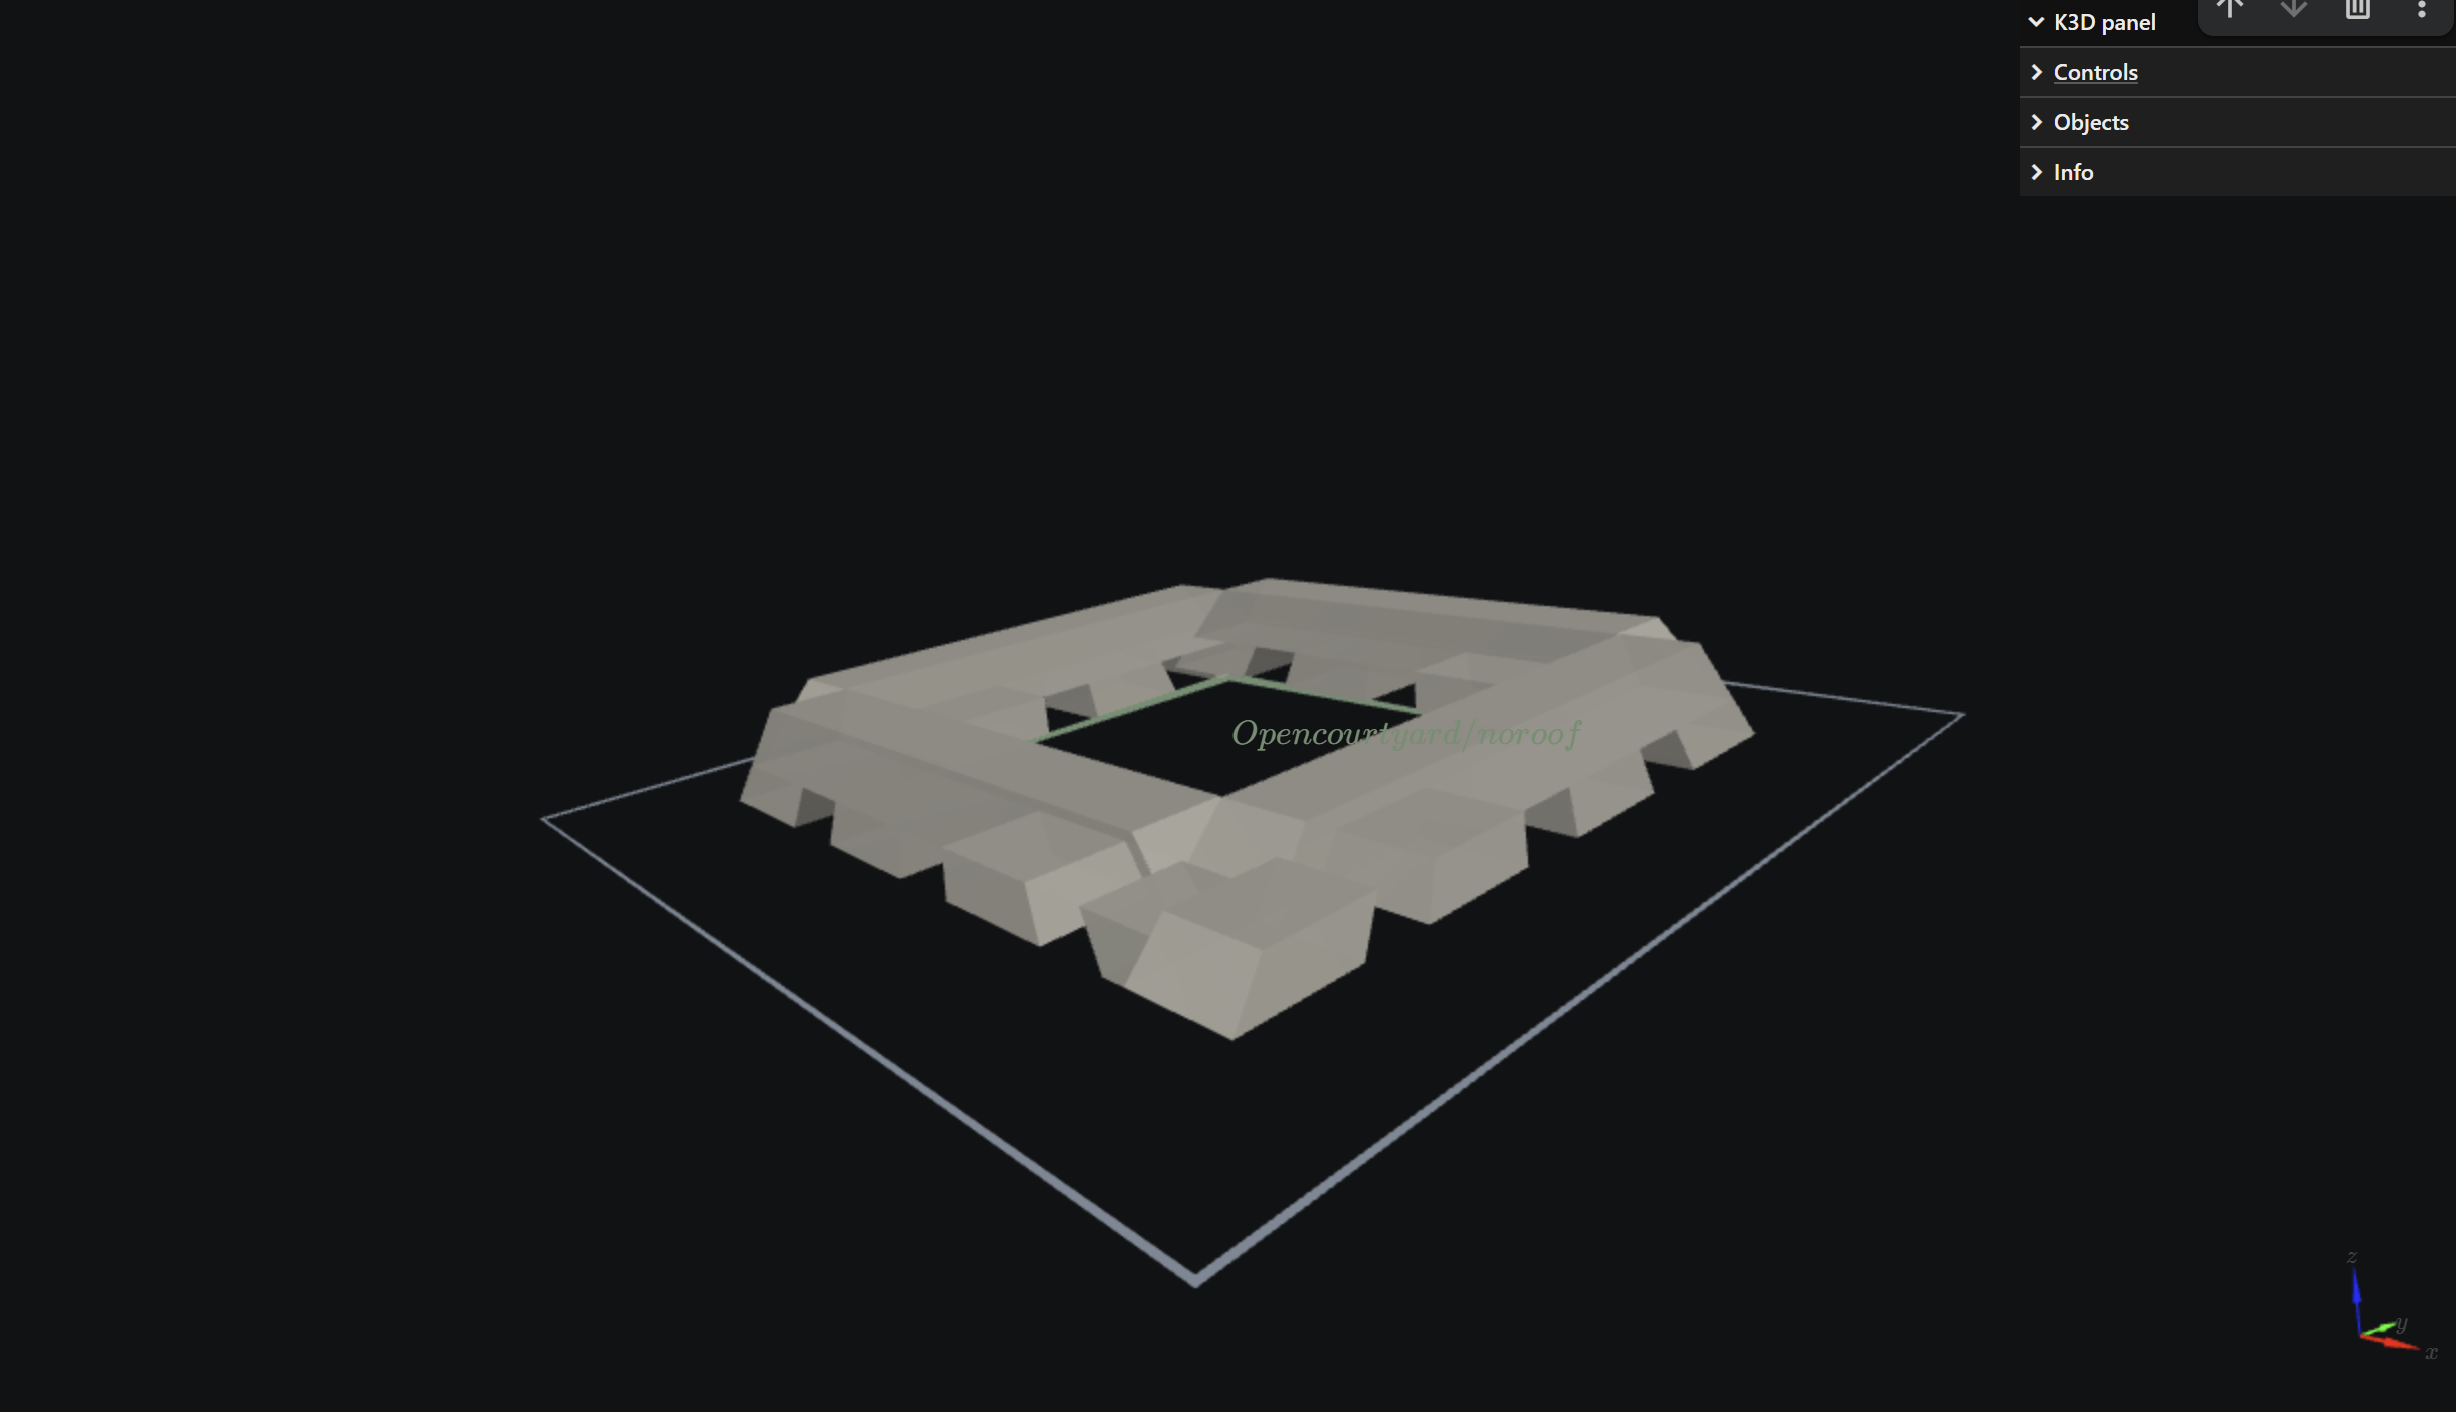